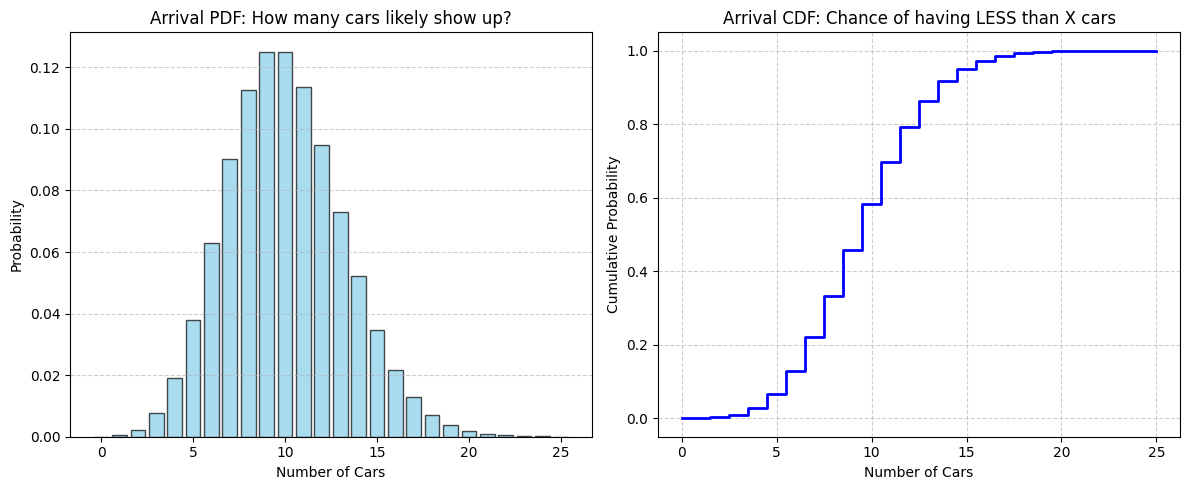

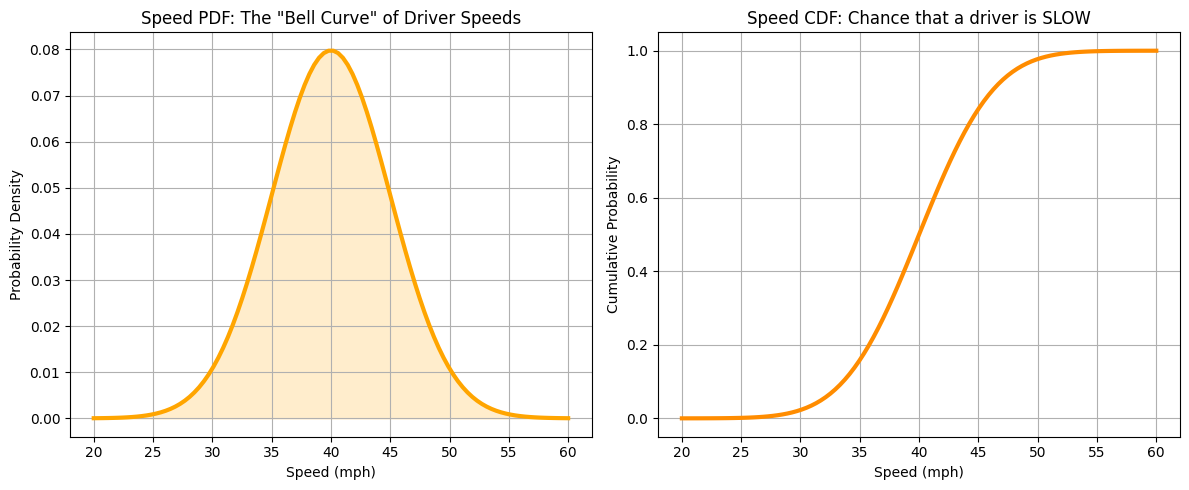

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

# 1. SETUP: Defining our "Typical" Traffic Day
# On average, 10 cars show up every minute (Lambda)
arrival_rate = 10
# Most drivers go 40 mph, but some go 30 or 50 (Mean and Std Dev)
avg_speed = 40
speed_spread = 5

# ---------------------------------------------------------
# 2. ARRIVAL UNCERTAINTY (Poisson Distribution)
# ---------------------------------------------------------
# We look at the probability of seeing 0 to 25 cars
cars_range = np.arange(0, 26)
arrival_pdf = poisson.pmf(cars_range, arrival_rate)
arrival_cdf = poisson.cdf(cars_range, arrival_rate)

plt.figure(figsize=(12, 5))

# Plotting the PDF (What is most likely to happen?)
plt.subplot(1, 2, 1)
plt.bar(cars_range, arrival_pdf, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Arrival PDF: How many cars likely show up?')
plt.xlabel('Number of Cars')
plt.ylabel('Probability')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Plotting the CDF (What is the "running total" chance?)
plt.subplot(1, 2, 2)
plt.step(cars_range, arrival_cdf, where='mid', color='blue', linewidth=2)
plt.title('Arrival CDF: Chance of having LESS than X cars')
plt.xlabel('Number of Cars')
plt.ylabel('Cumulative Probability')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. SPEED UNCERTAINTY (Normal Distribution)
# ---------------------------------------------------------
# We look at speeds from 20 mph to 60 mph
speed_range = np.linspace(20, 60, 100)
speed_pdf = norm.pdf(speed_range, avg_speed, speed_spread)
speed_cdf = norm.cdf(speed_range, avg_speed, speed_spread)

plt.figure(figsize=(12, 5))

# Plotting the PDF (The Bell Curve)
plt.subplot(1, 2, 1)
plt.plot(speed_range, speed_pdf, color='orange', linewidth=3)
plt.fill_between(speed_range, speed_pdf, color='orange', alpha=0.2)
plt.title('Speed PDF: The "Bell Curve" of Driver Speeds')
plt.xlabel('Speed (mph)')
plt.ylabel('Probability Density')
plt.grid(True)

# Plotting the CDF (Chance of a driver being slower than X)
plt.subplot(1, 2, 2)
plt.plot(speed_range, speed_cdf, color='darkorange', linewidth=3)
plt.title('Speed CDF: Chance that a driver is SLOW')
plt.xlabel('Speed (mph)')
plt.ylabel('Cumulative Probability')
plt.grid(True)

plt.tight_layout()
plt.show()

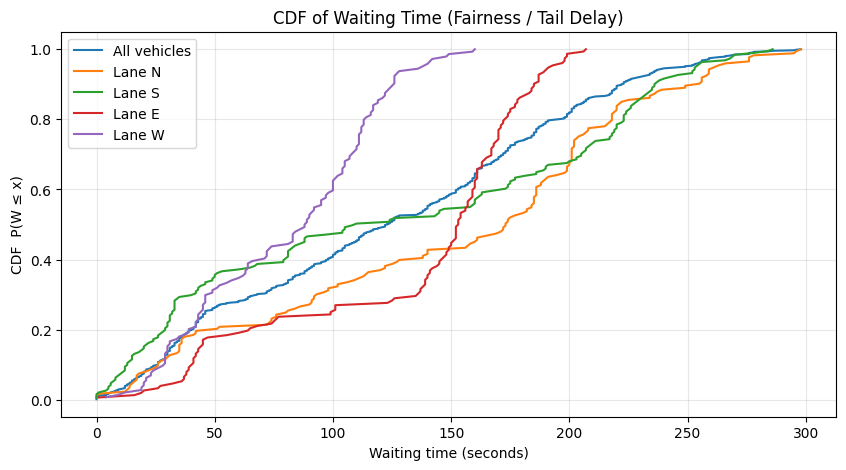

Total vehicles served: 660
Average waiting time (sec): 123.0439393939394
95th percentile wait (sec): 249.0


In [9]:

import numpy as np
import matplotlib.pyplot as plt
from collections import deque

np.random.seed(42)

# ---- Simulation configuration ----
SIM_MINUTES = 15
DT = 1  # seconds
T = SIM_MINUTES * 60 // DT

LANES = ["N", "S", "E", "W"]

# ---- ARRIVALS ----
arrival_rate_total = 60  #heavy

# Uneven demand looks more realistic (main road heavier)
lane_share = {"N": 0.30, "S": 0.30, "E": 0.20, "W": 0.20}
lambda_lane = {k: (arrival_rate_total * lane_share[k]) / 60.0 for k in LANES}  # cars/sec

PHASES = ["NS", "EW"]

# ---- Signal timing ----
MIN_GREEN = 10     # seconds: prevents jitter
MAX_GREEN = 35     # seconds: prevents starvation
LOST_TIME = 3      # seconds: yellow/all-red where nobody moves
DECISION_STEP = 1  # we simulate each second, decision happens internally

# ---- Fairness ----
USE_FAIRNESS = True
W_MAX = 60  # seconds: hard cap on how long a lane can go without being served

# ---- Service model (more realistic than 1–3 cars/sec) ----
# Assume saturation flow ~ 1 car per 2 seconds per green lane (≈ 1800 veh/hr/lane)
SAT_HEADWAY = 2.0  # seconds per car
# We'll probabilistically discharge at most 1 car per second per green lane:
# P(discharge) = 1/SAT_HEADWAY. Example: headway 2s → p=0.5 cars/sec on average.
DISCHARGE_PROB = 1.0 / SAT_HEADWAY


def lane_is_green(lane: str, phase: str) -> bool:
    return (phase == "NS" and lane in ("N", "S")) or (phase == "EW" and lane in ("E", "W"))


def choose_phase_weighted(queues, t, last_served):
    """
    Weighted randomized greedy:
      weight ~ queue sizes (+ optional fairness boost / hard cap)
    """
    qN, qS, qE, qW = len(queues["N"]), len(queues["S"]), len(queues["E"]), len(queues["W"])
    w_NS = qN + qS
    w_EW = qE + qW

    if USE_FAIRNESS:
        # Hard cap: if any lane waited too long and has cars, force the phase that serves it
        for lane in LANES:
            if len(queues[lane]) > 0 and (t - last_served[lane]) >= W_MAX:
                return "NS" if lane in ("N", "S") else "EW"

        # Soft fairness: add a small bonus based on "age"
        age_NS = 0
        age_EW = 0
        if qN > 0: age_NS += (t - last_served["N"])
        if qS > 0: age_NS += (t - last_served["S"])
        if qE > 0: age_EW += (t - last_served["E"])
        if qW > 0: age_EW += (t - last_served["W"])

        alpha = 1.0
        beta = 0.02
        w_NS = alpha * w_NS + beta * age_NS
        w_EW = alpha * w_EW + beta * age_EW

    total = w_NS + w_EW
    if total <= 0:
        return np.random.choice(PHASES)

    p_NS = w_NS / total
    return "NS" if np.random.rand() < p_NS else "EW"


# ---- State: queues store arrival times (FIFO) ----
queues = {lane: deque() for lane in LANES}
last_served = {lane: -10**9 for lane in LANES}

waiting_by_lane = {lane: [] for lane in LANES}
waiting_all = []

queue_len_ts = np.zeros((T, len(LANES)), dtype=int)

# phase controller internal state
current_phase = "NS"
phase_time = 0
in_lost_time = 0  # if >0, we're in yellow/all-red


for t in range(T):
    # 1) ARRIVALS
    for lane in LANES:
        arrivals = np.random.poisson(lambda_lane[lane])
        for _ in range(arrivals):
            queues[lane].append(t)

    # 2) SIGNAL PHASE UPDATE
    if in_lost_time > 0:
        in_lost_time -= 1
        # no service during lost time
    else:
        phase_time += 1

        # Decide whether to switch:
        # - must satisfy MIN_GREEN
        # - if we exceed MAX_GREEN, force a re-decision
        if phase_time >= MIN_GREEN:
            should_redo = (phase_time >= MAX_GREEN)

            # Greedy trigger: if opposing direction is much heavier
            qNS = len(queues["N"]) + len(queues["S"])
            qEW = len(queues["E"]) + len(queues["W"])
            imbalance = abs(qNS - qEW)
            trigger = (imbalance >= 6)  # tune threshold

            if should_redo or trigger:
                new_phase = choose_phase_weighted(queues, t, last_served)
                if new_phase != current_phase:
                    current_phase = new_phase
                    phase_time = 0
                    in_lost_time = LOST_TIME

        # 3) SERVICE (only if not in lost time)
        if in_lost_time == 0:
            for lane in LANES:
                if lane_is_green(lane, current_phase) and len(queues[lane]) > 0:
                    # probabilistic discharge based on saturation headway
                    if np.random.rand() < DISCHARGE_PROB:
                        arr_t = queues[lane].popleft()
                        wt = t - arr_t
                        waiting_by_lane[lane].append(wt)
                        waiting_all.append(wt)
                        last_served[lane] = t

    # 4) LOG QUEUES
    queue_len_ts[t, :] = [len(queues[l]) for l in LANES]


# =========================================================
# 5) PLOTS
# =========================================================

# A) Waiting time CDF (overall + per lane)
def plot_cdf(data, label):
    data = np.array(data, dtype=float)
    if len(data) == 0:
        return
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=label)

plt.figure(figsize=(10, 5))
plot_cdf(waiting_all, "All vehicles")
for lane in LANES:
    plot_cdf(waiting_by_lane[lane], f"Lane {lane}")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("CDF  P(W ≤ x)")
plt.title("CDF of Waiting Time (Fairness / Tail Delay)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Optional: quick sanity printouts
print("Total vehicles served:", len(waiting_all))
print("Average waiting time (sec):", float(np.mean(waiting_all)) if waiting_all else None)
print("95th percentile wait (sec):", float(np.percentile(waiting_all, 95)) if waiting_all else None)